In [ ]:
# @title Install requirements (1 ×) and mount Google Drive
!pip -q install einops seaborn lime tqdm

from google.colab import drive
drive.mount('/content/drive')        # ↳ follow the prompt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Mounted at /content/drive


In [ ]:
import os, glob, torch, pandas as pd, numpy as np, matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, f1_score, recall_score,
                             precision_recall_fscore_support)
from PIL import Image

In [ ]:
#@title Paths (edit!)
MODEL_PATH = "/content/drive/MyDrive/Undergrad thesis thingy/yt_excl_other_best_lr5e-05_bs128_do0.0.pth"  # ← .pth checkpoint
DATA_ROOT  = "/content/drive/MyDrive/Undergrad thesis thingy/Debate_OpticalFlow_Output_resize-exc-sampled-train"
LABEL_CSV  = "/content/label_debate_new_exclude20.csv"

In [ ]:
# ---------- label map (after removing ‘others’) -----------------
CSV2NAME = {1:'happiness', 3:'disgust', 4:'repression',
            5:'surprise', 6:'fear',    7:'sadness'}
CSV2NEW  = {old:new for new, old in enumerate(sorted(CSV2NAME))}  # {1:0,3:1,…}

N_CLASS   = len(CSV2NAME)   # = 6
IMG_SIZE  = 28

In [ ]:
# ---------- dataset ---------------------------------------------
class DebateFlowDatasetNoOther(Dataset):
    COLS = ["debat","segmen","part","me","label"]
    tfm  = T.Compose([
        T.Resize((IMG_SIZE,IMG_SIZE)),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    def __init__(self, csv_fp, root):
        self.samples = []
        df = pd.read_csv(csv_fp)
        for d,s,p,m,lbl in df[self.COLS].itertuples(index=False):
            if lbl == 2:                                       # skip “others”
                continue
            fname = f"Debat{d}-{s}-{p}-ME{m}.png"
            path  = os.path.join(root, f"Debat{d}", s, p, f"ME{m}", fname)
            if os.path.exists(path):
                self.samples.append((path, CSV2NEW[lbl]))      # remapped label

    def __len__(self):            return len(self.samples)
    def __getitem__(self, idx):
        path, lbl = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.tfm(img), lbl, path                       # keep path for vis


In [ ]:
from functools import partial
import torch
from torch import nn, einsum

from einops import rearrange
from einops.layers.torch import Rearrange, Reduce

def cast_tuple(val, depth):
    return val if isinstance(val, tuple) else ((val,) * depth)

class LayerNorm(nn.Module):
    def __init__(self, dim, eps = 1e-5):
        super().__init__()
        self.eps = eps
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))
        self.b = nn.Parameter(torch.zeros(1, dim, 1, 1))

    def forward(self, x):
        var = torch.var(x, dim = 1, unbiased = False, keepdim = True)
        mean = torch.mean(x, dim = 1, keepdim = True)
        return (x - mean) / (var + self.eps).sqrt() * self.g + self.b

class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)

class FeedForward(nn.Module):
    def __init__(self, dim, mlp_mult = 4, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(dim, dim * mlp_mult, 1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv2d(dim * mlp_mult, dim, 1),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dropout = 0.):
        super().__init__()
        dim_head = dim // heads
        inner_dim = dim_head * heads
        self.heads = heads
        self.scale = dim_head ** -0.5

        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)
        self.to_qkv = nn.Conv2d(dim, inner_dim * 3, 1, bias = False)

        self.to_out = nn.Sequential(
            nn.Conv2d(inner_dim, dim, 1),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        b, c, h, w, heads = *x.shape, self.heads

        qkv = self.to_qkv(x).chunk(3, dim = 1)
        q, k, v = map(lambda t: rearrange(t, 'b (h d) x y -> b h (x y) d', h = heads), qkv)

        dots = einsum('b h i d, b h j d -> b h i j', q, k) * self.scale

        attn = self.attend(dots)
        attn = self.dropout(attn)

        out = einsum('b h i j, b h j d -> b h i d', attn, v)
        out = rearrange(out, 'b h (x y) d -> b (h d) x y', x = h, y = w)
        return self.to_out(out)

def Aggregate(dim, dim_out):
    return nn.Sequential(
        nn.Conv2d(dim, dim_out, 3, padding = 1),
        LayerNorm(dim_out),
        nn.MaxPool2d(3, stride = 2, padding = 1)
    )

class Transformer(nn.Module):
    def __init__(self, dim, seq_len, depth, heads, mlp_mult, dropout = 0.):
        super().__init__()
        self.layers = nn.ModuleList([])
        self.pos_emb = nn.Parameter(torch.randn(seq_len))

        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads = heads, dropout = dropout)),
                PreNorm(dim, FeedForward(dim, mlp_mult, dropout = dropout))
            ]))
    def forward(self, x):
        *_, h, w = x.shape

        pos_emb = self.pos_emb[:(h * w)]
        pos_emb = rearrange(pos_emb, '(h w) -> () () h w', h = h, w = w)
        x = x + pos_emb

        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return x

class HTNet(nn.Module):
    def __init__(
        self,
        *,
        image_size,
        patch_size,
        num_classes,
        dim,
        heads,
        num_hierarchies,
        block_repeats,
        mlp_mult = 4,
        channels = 3,
        dim_head = 256,
        dropout = 0.
    ):
        super().__init__()
        assert (image_size % patch_size) == 0, 'Image dimensions must be divisible by the patch size.'
        patch_dim = channels * patch_size ** 2 #
        fmap_size = image_size // patch_size #
        blocks = 2 ** (num_hierarchies - 1)#

        seq_len = (fmap_size // blocks) ** 2   # sequence length is held constant across heirarchy
        hierarchies = list(reversed(range(num_hierarchies)))
        mults = [2 ** i for i in reversed(hierarchies)]

        layer_heads = list(map(lambda t: t * heads, mults))
        layer_dims = list(map(lambda t: t * dim, mults))
        last_dim = layer_dims[-1]

        layer_dims = [*layer_dims, layer_dims[-1]]
        dim_pairs = zip(layer_dims[:-1], layer_dims[1:])
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (p1 p2 c) h w', p1 = patch_size, p2 = patch_size),
            nn.Conv2d(patch_dim, layer_dims[0], 1),
        )

        block_repeats = cast_tuple(block_repeats, num_hierarchies)
        self.layers = nn.ModuleList([])
        for level, heads, (dim_in, dim_out), block_repeat in zip(hierarchies, layer_heads, dim_pairs, block_repeats):
            is_last = level == 0
            depth = block_repeat
            self.layers.append(nn.ModuleList([
                Transformer(dim_in, seq_len, depth, heads, mlp_mult, dropout),
                Aggregate(dim_in, dim_out) if not is_last else nn.Identity()
            ]))


        self.mlp_head = nn.Sequential(
            LayerNorm(last_dim),
            Reduce('b c h w -> b c', 'mean'),
            nn.Linear(last_dim, num_classes)
        )

    def forward(self, img):
        x = self.to_patch_embedding(img)
        b, c, h, w = x.shape
        num_hierarchies = len(self.layers)

        for level, (transformer, aggregate) in zip(reversed(range(num_hierarchies)), self.layers):
            block_size = 2 ** level
            x = rearrange(x, 'b c (b1 h) (b2 w) -> (b b1 b2) c h w', b1 = block_size, b2 = block_size)
            x = transformer(x)
            x = rearrange(x, '(b b1 b2) c h w -> b c (b1 h) (b2 w)', b1 = block_size, b2 = block_size)
            x = aggregate(x)
        return self.mlp_head(x)

# This function is to confuse three models
class Fusionmodel(nn.Module):
  def __init__(self):
    #  extend from original
    super(Fusionmodel,self).__init__()
    self.fc1 = nn.Linear(15, 3)
    self.bn1 = nn.BatchNorm1d(3)
    self.d1 = nn.Dropout(p=0.5)
    self.fc_2 = nn.Linear(6, 3)
    self.relu = nn.ReLU()
    # forward layers is to use these layers above
  def forward(self, whole_feature, l_eye_feature, l_lips_feature, nose_feature, r_eye_feature, r_lips_feature):
    fuse_four_features = torch.cat((l_eye_feature, l_lips_feature, nose_feature, r_eye_feature, r_lips_feature), 0)
    fuse_out = self.fc1(fuse_four_features)
    fuse_out = self.relu(fuse_out)
    fuse_out = self.d1(fuse_out) # drop out
    fuse_whole_four_parts = torch.cat(
        (whole_feature,fuse_out), 0)
    fuse_whole_four_parts = self.relu(fuse_whole_four_parts)
    fuse_whole_four_parts = self.d1(fuse_whole_four_parts)
    out = self.fc_2(fuse_whole_four_parts)
    return out

In [ ]:
import torch, torchvision.transforms as T, numpy as np, os
from torch.utils.data import Dataset, DataLoader
from PIL import Image

HT_PARAMS = dict(
    image_size      = 28,
    patch_size      = 7,
    num_classes     = N_CLASS,
    dim             = 256,
    heads           = 3,
    num_hierarchies = 3,
    block_repeats   = (2, 2, 6),
    dropout         = 0.0,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# assumes `HTNet` definition already executed (from Model.py)
model = HTNet(**HT_PARAMS).to(device)
ckpt  = torch.load(MODEL_PATH, map_location=device)
if isinstance(ckpt, dict) and 'state_dict' in ckpt:           # Lightning ckpt
    ckpt = {k.replace('model.', ''): v for k, v in ckpt['state_dict'].items()}
model.load_state_dict(ckpt)
model.eval();

In [ ]:
model

HTNet(
  (to_patch_embedding): Sequential(
    (0): Rearrange('b c (h p1) (w p2) -> b (p1 p2 c) h w', p1=7, p2=7)
    (1): Conv2d(147, 256, kernel_size=(1, 1), stride=(1, 1))
  )
  (layers): ModuleList(
    (0): ModuleList(
      (0): Transformer(
        (layers): ModuleList(
          (0-1): 2 x ModuleList(
            (0): PreNorm(
              (norm): LayerNorm()
              (fn): Attention(
                (attend): Softmax(dim=-1)
                (dropout): Dropout(p=0.0, inplace=False)
                (to_qkv): Conv2d(256, 765, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (to_out): Sequential(
                  (0): Conv2d(255, 256, kernel_size=(1, 1), stride=(1, 1))
                  (1): Dropout(p=0.0, inplace=False)
                )
              )
            )
            (1): PreNorm(
              (norm): LayerNorm()
              (fn): FeedForward(
                (net): Sequential(
                  (0): Conv2d(256, 1024, kernel_size=(1, 1), stride

In [ ]:
CSV_PATH = LABEL_CSV

In [ ]:
# ---------- inference -------------------------------------------
ds  = DebateFlowDatasetNoOther(CSV_PATH, DATA_ROOT)
ld  = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

In [ ]:
len(ds)

98

In [ ]:
import os, pandas as pd

CSV      = "/content/label_debate_new_exclude20.csv"
DATAROOT = DATA_ROOT
COLS     = ["debat","segmen","part","me","label"]


In [ ]:
missing = []
df = pd.read_csv(CSV)
for d,s,p,m,lbl in df[COLS].itertuples(index=False):
    if lbl == 2:                                  # skip "others"
        continue
    fname = f"Debat{d}-{s}-{p}-ME{m}.png"
    path  = os.path.join(DATAROOT, f"Debat{d}", s, p, f"ME{m}", fname)
    if not os.path.exists(path):
        missing.append(path)

print(f"{len(missing)} files missing:")
for p in missing:
    print("  ", p)

0 files missing:


In [ ]:
# prepare storage
y_true, y_pred = [], []
records = []

# inference + record gathering
with torch.no_grad():
    for xb, yb, paths in ld:
        logits = model(xb.to(device))
        probs  = F.softmax(logits, dim=1).cpu()               # get probabilities
        preds  = probs.argmax(1).tolist()

        y_pred.extend(preds)
        y_true.extend(yb.tolist())

        # store per-sample info for gallery()
        for i, pth in enumerate(paths):
            true_lbl = int(yb[i].item())
            pred_lbl = int(preds[i])
            conf     = float(probs[i, pred_lbl])
            records.append({
                "path": pth,
                "true0": true_lbl,
                "pred0": pred_lbl,
                "conf": conf
            })


In [ ]:
# ---------- metrics ---------------------------------------------
acc  = accuracy_score(y_true, y_pred)
prec, rec, f1w, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0)
uf1  = f1_score (y_true, y_pred, average='macro',  zero_division=0)
uar  = recall_score(y_true, y_pred, average='macro', zero_division=0)

print(f"\nAccuracy  : {acc:.4f}")
print(f"W-Prec/R/F: {prec:.4f} / {rec:.4f} / {f1w:.4f}")
print(f"UF1       : {uf1:.4f}")
print(f"UAR       : {uar:.4f}\n")

new_names = [CSV2NAME[old] for old in sorted(CSV2NAME)]
print(classification_report(y_true, y_pred,
      labels=range(N_CLASS), target_names=new_names, zero_division=0))


Accuracy  : 0.5918
W-Prec/R/F: 0.6863 / 0.5918 / 0.6271
UF1       : 0.3158
UAR       : 0.3231

              precision    recall  f1-score   support

   happiness       0.52      0.54      0.53        28
     disgust       0.25      0.25      0.25         4
  repression       0.25      0.45      0.32        11
    surprise       0.93      0.70      0.80        53
        fear       0.00      0.00      0.00         2
     sadness       0.00      0.00      0.00         0

    accuracy                           0.59        98
   macro avg       0.32      0.32      0.32        98
weighted avg       0.69      0.59      0.63        98



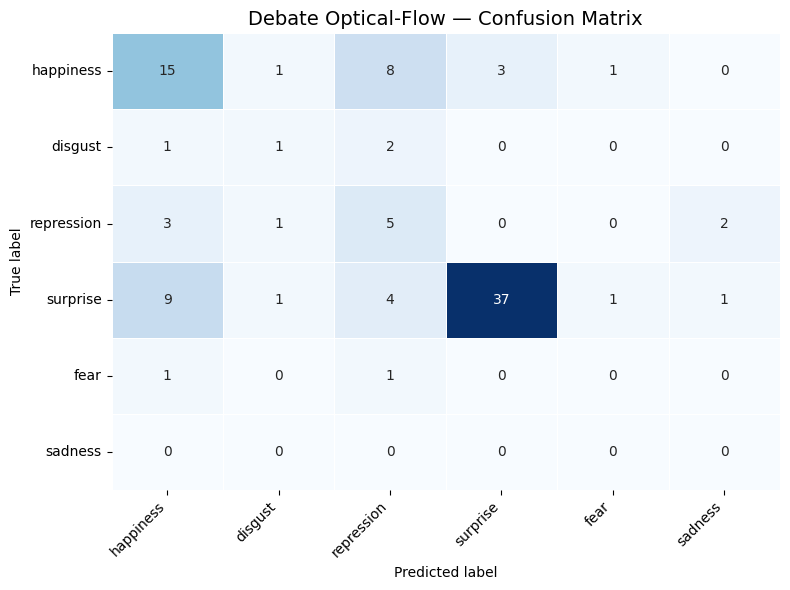

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns, pandas as pd, matplotlib.pyplot as plt

# 1) define your 6 labels
CSV2NAME    = {1:'happiness', 3:'disgust', 4:'repression',
               5:'surprise', 6:'fear',    7:'sadness'}
class_names = [CSV2NAME[k] for k in sorted(CSV2NAME)]

# 2) compute raw counts
cm_counts = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

# 3) plot only the counts matrix
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
sns.heatmap(
    pd.DataFrame(cm_counts, index=class_names, columns=class_names),
    annot=True, fmt="d", cmap="Blues", cbar=False,
    linewidths=0.5, linecolor="white", ax=ax
)
ax.set_title("Debate Optical-Flow — Confusion Matrix", fontsize=14)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
import random
import numpy as np
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt

class_names = [CSV2NAME[k] for k in sorted(CSV2NAME)]
N_CLASS     = len(class_names)
LABELS      = class_names

def gallery(records, k=6, thumb=1.3):
    """
    Display up to *k* random samples per true label.
    Blue = correct, red = wrong.
    """
    # 1) cluster by true label
    by_true = defaultdict(list)
    for r in records:
        by_true[r['true0']].append(r)

    # only labels that have data
    labels_present = [lbl for lbl in range(N_CLASS) if by_true[lbl]]
    if not labels_present:
        print("⚠️ No samples found in `records`.")
        return

    n_rows, n_cols = len(labels_present), k

    # 2) sample up to k per label
    sampled = {
        lbl: random.sample(by_true[lbl], min(k, len(by_true[lbl])))
        for lbl in labels_present
    }

    # 3) figure grid
    fig_w = n_cols * thumb + 2
    fig_h = n_rows * thumb + 1
    plt.close("all")
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    plt.subplots_adjust(top=0.9, hspace=0.45, wspace=0.05)

    for row_idx, lbl in enumerate(labels_present):
        row_recs = sampled[lbl]
        for col in range(n_cols):
            ax = axes[row_idx, col]
            ax.axis("off")
            if col < len(row_recs):
                rec = row_recs[col]
                ax.imshow(Image.open(rec["path"]), interpolation="bilinear")
                ok  = rec["true0"] == rec["pred0"]
                c   = "blue" if ok else "red"
                ax.set_title(
                    f"T:{LABELS[rec['true0']]}\n"
                    f"P:{LABELS[rec['pred0']]} ({rec['conf']:.2f})",
                    color=c, fontsize=7, pad=4
                )

        # big row label
        axes[row_idx, 0].set_ylabel(
            LABELS[lbl],
            rotation=0, labelpad=40,
            va="center", fontsize=9
        )

    fig.suptitle(
        f"{k} Random Samples per True Label (blue = correct, red = wrong)",
        fontsize=14
    )
    plt.show()

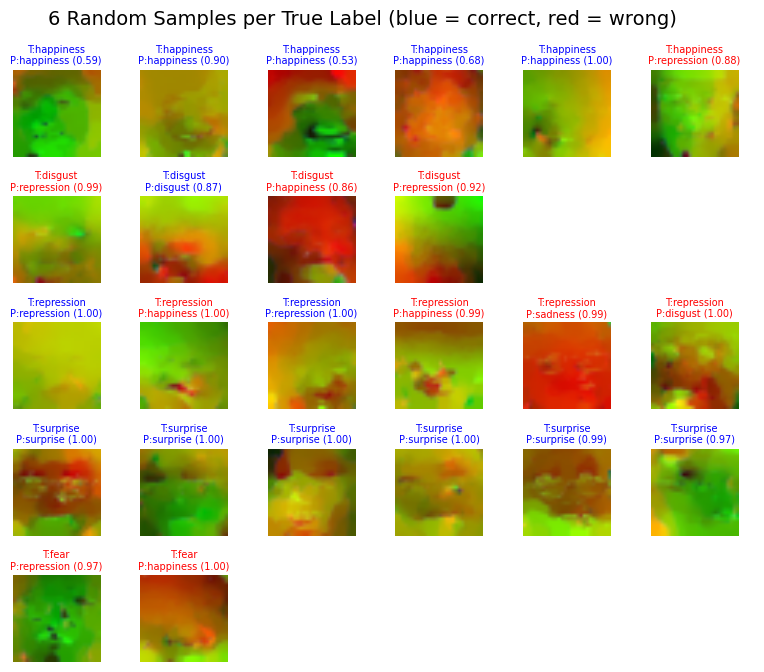

In [ ]:
# ─── finally call it ───────────────────────────────────────────────
gallery(records, k=6, thumb=1.3)

In [ ]:
# -------------------------------------------------------------
#   LIME VISUALISER FOR 6-CLASS MODEL (NO 'OTHERS')
# -------------------------------------------------------------
import torch, numpy as np, matplotlib.pyplot as plt, torch.nn.functional as F
from lime import lime_image
from skimage.segmentation import slic
import matplotlib.cm as cm
from PIL import Image
import torchvision.transforms as T, collections, os

# 0) Updated constants for 6-class model
CSV2NAME = {1:'happiness', 3:'disgust', 4:'repression',
            5:'surprise', 6:'fear', 7:'sadness'}
# Create reverse mapping from class index to name
LABELS = {idx: CSV2NAME[orig] for idx, orig in enumerate(sorted(CSV2NAME))}
N_CLASSES = len(LABELS)  # Should be 6

lime_tf = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225])
])
device = next(model.parameters()).device

# ====================== Precompute predictions ======================
# Use your existing evaluation records
correct_examples = {i: [] for i in range(N_CLASSES)}
incorrect_examples = {i: [] for i in range(N_CLASSES)}

for record in records:
    true_label = record['true0']
    pred_label = record['pred0']
    if true_label == pred_label:
        correct_examples[true_label].append(record)
    else:
        incorrect_examples[true_label].append(record)

# ====================== Visualization Functions ======================
def run_lime_for_record(record):
    """Run LIME explanation for a record"""
    path = record['path']
    np_img = np.array(Image.open(path).convert('RGB').resize((64,64)))

    # Lime prediction function
    def lime_predict(imgs):
        batch = torch.stack([
            lime_tf(Image.fromarray(i).resize((28,28)))
            for i in imgs
        ]).to(device)
        with torch.no_grad():
            return F.softmax(model(batch),1).detach().cpu().numpy()

    # Run LIME
    explainer = lime_image.LimeImageExplainer()
    exp = explainer.explain_instance(
        np_img, lime_predict,
        segmentation_fn=lambda img: slic(img, n_segments=30, compactness=5, sigma=1),
        top_labels=1,
        num_features=30,
        num_samples=1200,
        hide_color=0
    )
    lab_id = exp.top_labels[0]

    # Generate masks
    _, pos_m = exp.get_image_and_mask(lab_id, positive_only=True, num_features=30)
    _, neg_m = exp.get_image_and_mask(lab_id, positive_only=False, negative_only=True, num_features=30)

    # Generate heatmap
    segments = exp.segments
    heat = np.zeros_like(segments, dtype=float)
    for sid, w in exp.local_exp[lab_id]:
        heat[segments == sid] = w
    norm = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    heat_rgb = cm.seismic(norm)[:, :, :3]
    weighted = 0.55 * heat_rgb + 0.45 * np_img / 255.0

    return {
        'img64': np_img,
        'pos_m': pos_m,
        'neg_m': neg_m,
        'weighted': weighted,
        'record': record
    }

def filled_overlay(base, mask, color):
    overlay = base.copy()
    overlay[mask] = 0.6 * base[mask] + 0.4 * np.array(color)
    return overlay

def create_compact_plot(data, correctness):
    """Create compact visualization with weighted map"""
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))

    # Get record data
    record = data['record']
    true_label = record['true0']
    pred_label = record['pred0']
    conf = record['conf']

    # Color based on correctness
    title_color = 'blue' if correctness == 'correct' else 'red'

    # 1) Original image
    axs[0].imshow(data['img64'])
    axs[0].set_title("Original", fontsize=9)
    axs[0].axis('off')

    # 2) Positive supports
    pos_filled = filled_overlay(data['img64']/255.0, data['pos_m'].astype(bool), [0,1,0])
    axs[1].imshow(pos_filled)
    axs[1].set_title("+ Supports", fontsize=9)
    axs[1].axis('off')

    # 3) Negative opposes
    neg_filled = filled_overlay(data['img64']/255.0, data['neg_m'].astype(bool), [1,0,0])
    axs[2].imshow(neg_filled)
    axs[2].set_title("- Opposes", fontsize=9)
    axs[2].axis('off')

    # 4) Weighted heatmap
    axs[3].imshow(data['weighted'])
    axs[3].set_title("Weighted Map", fontsize=9)
    axs[3].axis('off')

    # 5) Confidence display
    axs[4].text(0.5, 0.5,
               f"True: {LABELS[true_label]}\nPred: {LABELS[pred_label]}\nConf: {conf:.2f}",
               ha='center', va='center', fontsize=11)
    axs[4].axis('off')

    # Add colorbar
    cax = fig.add_axes([0.25, 0.08, 0.5, 0.03])
    cb = plt.colorbar(cm.ScalarMappable(cmap='seismic'), cax=cax, orientation='horizontal')
    cb.set_ticks([0, 0.5, 1])
    cb.set_ticklabels(['strong −', '0', 'strong +'], fontsize=8)

    # Main title
    fig.suptitle(
        f"{correctness.upper()}: {os.path.basename(record['path'])}",
        color=title_color, fontsize=12, y=0.99
    )

    plt.tight_layout(rect=[0, 0.1, 1, 0.92])
    return fig

# ====================== Generate Visualizations ======================
# Create visualizations for all classes with examples
for class_idx in range(N_CLASSES):
    class_name = LABELS[class_idx]

    # Correct examples
    if correct_examples[class_idx]:
        # Get highest confidence correct example
        examples = sorted(correct_examples[class_idx], key=lambda x: x['conf'], reverse=True)
        record = examples[0]
        data = run_lime_for_record(record)
        fig = create_compact_plot(data, 'correct')
        fig.savefig(f"LIME_{class_name}_correct.png", dpi=150, bbox_inches='tight')
        plt.close(fig)

    # Incorrect examples
    if incorrect_examples[class_idx]:
        # Get highest confidence incorrect example
        examples = sorted(incorrect_examples[class_idx], key=lambda x: x['conf'], reverse=True)
        record = examples[0]
        data = run_lime_for_record(record)
        fig = create_compact_plot(data, 'incorrect')
        fig.savefig(f"LIME_{class_name}_incorrect.png", dpi=150, bbox_inches='tight')
        plt.close(fig)

  0%|          | 0/1200 [00:00<?, ?it/s]

/tmp/ipython-input-20-1212191840.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.92])


  0%|          | 0/1200 [00:00<?, ?it/s]

/tmp/ipython-input-20-1212191840.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.92])


  0%|          | 0/1200 [00:00<?, ?it/s]

...

/tmp/ipython-input-20-1212191840.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.92])


  0%|          | 0/1200 [00:00<?, ?it/s]

/tmp/ipython-input-20-1212191840.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.92])


  0%|          | 0/1200 [00:00<?, ?it/s]

/tmp/ipython-input-20-1212191840.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.92])
